# Correlation on Episode Outcomes

Download the data zip folder from here: https://byu.app.box.com/file/1911163633278

Unzip it and put it in this directory. 

In [88]:
#unzip training_metrics.zip
import zipfile
import os

with zipfile.ZipFile("data.zip", "r") as zip_ref:
    zip_ref.extractall(".")

#remove the zip file
os.remove("data.zip")

In [89]:
import json
import pandas as pd
import plotly.express as px
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [90]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

In [91]:
def plot_correlation(correlation, runid, ax):
    mask = np.tril(np.ones_like(correlation, dtype=bool))
    sns.heatmap(
        correlation,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="bwr",
        cbar=True,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor="black",
        ax=ax,
        annot_kws={"size": 14}  # Increase annotation font size
    )
    ax.tick_params(axis='both', labelsize=12)  # Increase tick label font size

File: data/lifting_trials_k1b5sgl8_lhs_1000_rl_model_38997816_steps.txt
Average Success Rate: 0.941
Average Tip Rate: 0.025
Average Slip Rate: 0.034
Sanity Check: 1.0



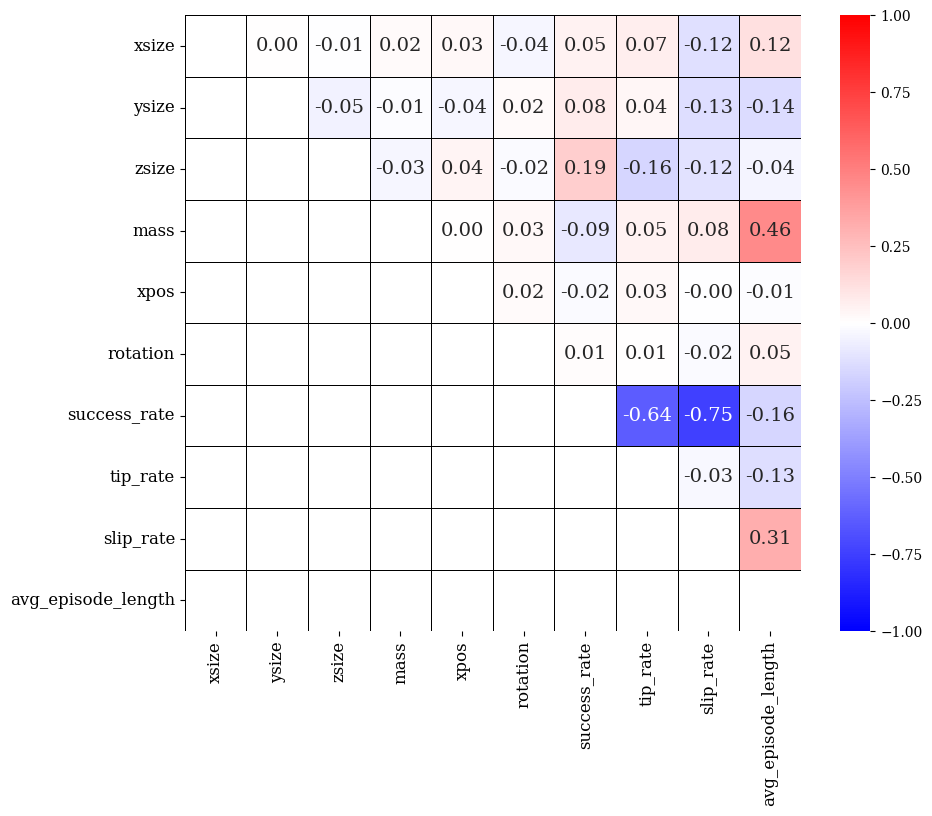

File: data/lifting_trials_baseline_lhs_1000_hugger.txt
Average Success Rate: 0.931
Average Tip Rate: 0.019
Average Slip Rate: 0.05
Sanity Check: 1.0



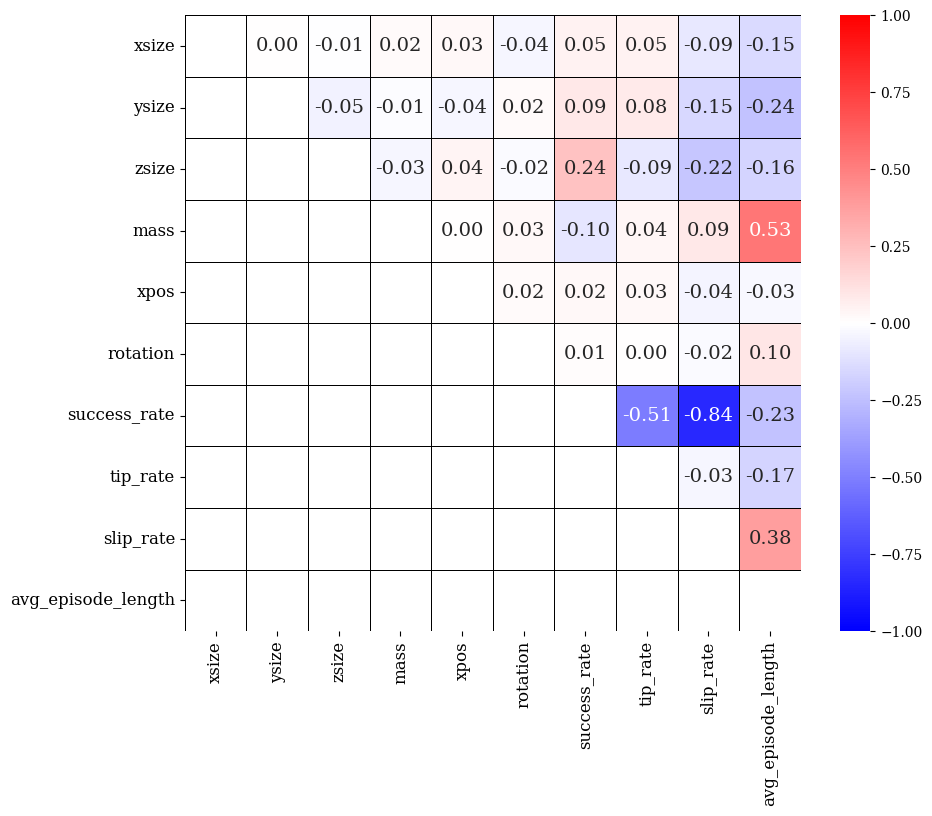

In [97]:
data_files = glob.glob("data/lifting_trials*.txt")
for file_path in data_files:
    # Initialize variables to store the total success rate and the number of trials
    successes = 0
    tips = 0
    slips = 0
    num_trials = 0
    data = []

    # Read the JSON data from the file
    with open(file_path, "r") as f:
        for line in f:
            trial_data = json.loads(line)
            successes += trial_data["success_rate"]
            tips += trial_data["tip_rate"]
            slips += trial_data["slip_rate"]
            num_trials += 1
            data.append(trial_data)

    # Calculate the average success rate
    average_success_rate = successes / num_trials if num_trials > 0 else 0
    average_tip_rate = tips / num_trials if num_trials > 0 else 0
    average_slip_rate = slips / num_trials if num_trials > 0 else 0

    # Print rates
    print(f"File: {file_path}")
    print(f"Average Success Rate: {average_success_rate}")
    print(f"Average Tip Rate: {average_tip_rate}")
    print(f"Average Slip Rate: {average_slip_rate}")
    print(
        f"Sanity Check: {average_tip_rate + average_slip_rate + average_success_rate}\n"
    )

    #perform correlation analysis on over all trials against sizes and mass
    data = pd.DataFrame(data)

    correlation_matrix = data.corr("spearman")
    #spearman b/c it doesn't assume linear relationships, only monotonic ones
    #1 means Perfect monotonic increasing relationship (as one variable increases, the other always increases).

    fig, ax = plt.subplots(figsize=(10, 8))
    plot_correlation(correlation_matrix, os.path.basename(file_path), ax)
    plt.savefig(
        f"data/correlation_matrix_{os.path.basename(file_path).replace('.txt', '')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show(block=False)


# How learning affected the outcomes

In [98]:
import pandas as pd

learned_policy = pd.read_json("./data/lifting_trials_k1b5sgl8_lhs_1000_rl_model_38997816_steps.txt", lines=True)
baseline = pd.read_json("./data/lifting_trials_baseline_lhs_1000_hugger.txt", lines=True)

# Define the key columns for merging
key_cols = ['xsize', 'ysize', 'zsize', 'mass', 'xpos', 'rotation']

# Merge on those columns with suffixes to distinguish the two datasets
merged_df = pd.merge(baseline, learned_policy, on=key_cols, suffixes=('_baseline', '_learned'))

merged_df.head()

,xsize,ysize,zsize,mass,xpos,rotation,success_rate_baseline,tip_rate_baseline,slip_rate_baseline,avg_episode_length_baseline,success_rate_learned,tip_rate_learned,slip_rate_learned,avg_episode_length_learned
0,0.242245,0.234312,0.422928,1.072875,0.051219,0.833620,True,False,0,1042,True,False,0,1045
1,0.120048,0.272243,0.451702,5.027221,0.013726,0.881587,True,False,0,1065,True,False,0,1069
2,0.294071,0.138035,0.453834,2.236341,0.063911,0.762493,True,False,0,1046,True,False,0,1043
3,0.176834,0.227874,0.594341,8.837632,0.038006,0.362107,True,False,0,1056,True,False,0,1060
4,0.255244,0.179161,0.505200,4.936084,0.082231,0.708569,True,False,0,1055,True,False,0,1075


In [99]:
def label_outcome(row, prefix):
    if row[f'tip_rate_{prefix}']:
        return 'tip'
    elif row[f'slip_rate_{prefix}'] > 0:
        return 'slip'
    elif row[f'success_rate_{prefix}']:
        return 'success'


merged_df['baseline_outcome'] = merged_df.apply(lambda row: label_outcome(row, 'baseline'), axis=1)
merged_df['learned_outcome'] = merged_df.apply(lambda row: label_outcome(row, 'learned'), axis=1)
merged_df

,xsize,ysize,zsize,mass,xpos,rotation,success_rate_baseline,tip_rate_baseline,slip_rate_baseline,avg_episode_length_baseline,success_rate_learned,tip_rate_learned,slip_rate_learned,avg_episode_length_learned,baseline_outcome,learned_outcome
0,0.242245,0.234312,0.422928,1.072875,0.051219,0.833620,True,False,0,1042,True,False,0,1045,success,success
1,0.120048,0.272243,0.451702,5.027221,0.013726,0.881587,True,False,0,1065,True,False,0,1069,success,success
2,0.294071,0.138035,0.453834,2.236341,0.063911,0.762493,True,False,0,1046,True,False,0,1043,success,success
3,0.176834,0.227874,0.594341,8.837632,0.038006,0.362107,True,False,0,1056,True,False,0,1060,success,success
4,0.255244,0.179161,0.505200,4.936084,0.082231,0.708569,True,False,0,1055,True,False,0,1075,success,success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.260523,0.205391,0.391549,2.457044,0.036994,0.454947,True,False,0,1037,True,False,0,1048,success,success
996,0.210849,0.285531,0.536815,4.540674,0.021900,0.287897,True,False,0,1055,True,False,0,1055,success,success
997,0.100235,0.183333,0.270000,5.997021,0.088591,0.849533,True,False,0,1086,True,False,0,1082,success,success
998,0.181010,0.225303,0.572459,3.058466,0.015007,0.427064,True,False,0,1036,True,False,0,1043,success,success


In [100]:
transition_counts = merged_df.groupby(['baseline_outcome', 'learned_outcome'
                                       ]).size().reset_index(name='count')
transition_counts

,baseline_outcome,learned_outcome,count
0,slip,slip,27
1,slip,success,13
2,slip,tip,10
3,success,slip,6
4,success,success,922
5,success,tip,3
6,tip,slip,1
7,tip,success,6
8,tip,tip,12


In [101]:
import plotly.graph_objects as go

def create_sankey_diagram(transition_counts, outcome_labels, title="Baseline → Learned Outcome Transitions"):
    """
    Creates a Sankey diagram showing transitions from baseline outcomes to learned outcomes.

    Parameters:
    - transition_counts: DataFrame with columns ['baseline_outcome', 'learned_outcome', 'count']
    - outcome_labels: list of unique outcome labels (e.g. ['success', 'slipped', 'tipped'])
    - title: figure title string
    """

    # Map outcome labels to node indices
    label_to_index = {label: idx for idx, label in enumerate(outcome_labels)}
    
    # Sources (baseline nodes)
    source_indices = transition_counts['baseline_outcome'].map(label_to_index).tolist()
    # Targets (learned nodes), offset by number of baseline nodes to place on right
    target_indices = transition_counts['learned_outcome'].map(lambda x: label_to_index[x] + len(outcome_labels)).tolist()
    
    # Flow values (number of trials)
    values = transition_counts['count'].tolist()
    
    # All node labels: baseline + learned (duplicated for left and right columns)
    node_labels = outcome_labels + outcome_labels

    # Optional: define consistent colors for nodes
    node_colors = ['#4C78A8', '#F58518', '#E45756'] * 2  # repeat for baseline and learned
    
    # Build Sankey diagram
    sankey_fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color='black', width=0.5),
            label=node_labels,
            color=node_colors,
            hovertemplate='%{label}<extra></extra>'
        ),
        link=dict(
            source=source_indices,
            target=target_indices,
            value=values,
            color='rgba(150, 150, 150, 0.4)',  # semi-transparent grey links
            hovertemplate='Count: %{value}<extra></extra>'
        )
    )])

    # Update layout with professional formatting
    sankey_fig.update_layout(
        title_text=None,
        font=dict(size=24, family='Times New Roman, Times, serif'),
        height=400,
        margin=dict(l=30, r=30, t=50, b=20),  # add bottom margin for labels
        annotations=[
            dict(
                x=0.02,  # left group
                y=1.15,  # slightly below the plot (negative to go below axis)
                text="Baseline",
                showarrow=False,
                font=dict(size=24, family='Times New Roman, Times, serif'),
                xanchor='center',
                yanchor='top'  # align text above this y-position
            ),
            dict(
                x=0.98,  # right group
                y=1.15,
                text="Learned",
                showarrow=False,
                font=dict(size=24, family='Times New Roman, Times, serif'),
                xanchor='center',
                yanchor='top'
            )
        ]
    )

    return sankey_fig

# Usage example:
fig = create_sankey_diagram(transition_counts, ['success', 'slip', 'tip'])
fig.show()

In [102]:
# Create pivot table (transition matrix)
transition_matrix = transition_counts.pivot(
    index='baseline_outcome',
    columns='learned_outcome',
    values='count'
).fillna(0).astype(int)

print(transition_matrix)

learned_outcome   slip  success  tip
baseline_outcome                    
slip                27       13   10
success              6      922    3
tip                  1        6   12


## Did learning statistically affect outcomes?

using stuart-maxwell test b/c my data is technically paired (since each box was used for a baseline run and a learned run. If they were independent chi square would be the test with the contingency table. )

In [103]:
import numpy as np
from statsmodels.stats.contingency_tables import SquareTable

table = SquareTable(transition_matrix)

results = table.homogeneity(method="stuart_maxwell")
print(f"chi2 stat:{results.statistic}, pvalue:{results.pvalue}, dof:{results.df}")

chi2 stat:8.534446764091857, pvalue:0.014020659170418726, dof:2


So yes, it appears that training DID have an effect on the outcomes. This test does not tell us HOW though, just that it DID. 

# Training Metrics Plots


Download the trainin metrics from here: https://byu.app.box.com/file/1911151751594

Place training_data.zip in this directory and unzip it.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np

In [ ]:
#unzip training_metrics.zip
import zipfile
import os

with zipfile.ZipFile("training_metrics.zip", "r") as zip_ref:
    zip_ref.extractall(".")

#remove the zip file
os.remove("training_metrics.zip")

BadZipFile: File is not a zip file

In [55]:
guided_eval_success_files = glob.glob("training_metrics/guided_reward/eval/success_rate.csv")
print(f"Evaluation Success Rate Files: \n{guided_eval_success_files}\n")

guided_eval_ep_len_files = glob.glob("training_metrics/guided_reward/eval/ep_len_mean.csv")
print(f"Evaluation Episode Length Files: \n{guided_eval_ep_len_files}\n")

guided_eval_ep_rew_files = glob.glob("training_metrics/guided_reward/eval/mean_reward.csv")
print(f"Evaluation Episode Reward Files: \n{guided_eval_ep_rew_files}\n")

guided_rollout_success_files = glob.glob(
    "training_metrics/guided_reward/rollout/success_rate.csv")
print(f"Rollout Success Rate Files: \n{guided_rollout_success_files}\n")

guided_rollout_ep_len_files = glob.glob(
    "training_metrics/guided_reward/rollout/ep_len_mean.csv")
print(f"Rollout Episode Length Files: \n{guided_rollout_ep_len_files}\n")

guided_rollout_ep_rew_files = glob.glob(
    "training_metrics/guided_reward/rollout/mean_reward.csv")
print(f"Rollout Episode Reward Files: \n{guided_rollout_ep_rew_files}\n")

Evaluation Success Rate Files: 
['training_metrics/guided_reward/eval/success_rate.csv']

Evaluation Episode Length Files: 
['training_metrics/guided_reward/eval/ep_len_mean.csv']

Evaluation Episode Reward Files: 
['training_metrics/guided_reward/eval/mean_reward.csv']

Rollout Success Rate Files: 
['training_metrics/guided_reward/rollout/success_rate.csv']

Rollout Episode Length Files: 
['training_metrics/guided_reward/rollout/ep_len_mean.csv']

Rollout Episode Reward Files: 
['training_metrics/guided_reward/rollout/mean_reward.csv']



In [56]:
shaped_eval_success_files = glob.glob("training_metrics/shaped_reward/eval/success_rate.csv")
print(f"Evaluation Success Rate Files: \n{shaped_eval_success_files}\n")

shaped_eval_ep_len_files = glob.glob("training_metrics/shaped_reward/eval/ep_len_mean.csv")
print(f"Evaluation Episode Length Files: \n{shaped_eval_ep_len_files}\n")

shaped_eval_ep_rew_files = glob.glob("training_metrics/shaped_reward/eval/mean_reward.csv")
print(f"Evaluation Episode Reward Files: \n{shaped_eval_ep_rew_files}\n")

shaped_rollout_success_files = glob.glob(
    "training_metrics/shaped_reward/rollout/success_rate.csv")
print(f"Rollout Success Rate Files: \n{shaped_rollout_success_files}\n")

shaped_rollout_ep_len_files = glob.glob(
    "training_metrics/shaped_reward/rollout/ep_len_mean.csv")
print(f"Rollout Episode Length Files: \n{shaped_rollout_ep_len_files}\n")

shaped_rollout_ep_rew_files = glob.glob(
    "training_metrics/shaped_reward/rollout/mean_reward.csv")
print(f"Rollout Episode Reward Files: \n{shaped_rollout_ep_rew_files}\n")

Evaluation Success Rate Files: 
['training_metrics/shaped_reward/eval/success_rate.csv']

Evaluation Episode Length Files: 
['training_metrics/shaped_reward/eval/ep_len_mean.csv']

Evaluation Episode Reward Files: 
['training_metrics/shaped_reward/eval/mean_reward.csv']

Rollout Success Rate Files: 
['training_metrics/shaped_reward/rollout/success_rate.csv']

Rollout Episode Length Files: 
['training_metrics/shaped_reward/rollout/ep_len_mean.csv']

Rollout Episode Reward Files: 
['training_metrics/shaped_reward/rollout/mean_reward.csv']



In [57]:
def read_csvs(files: list):
    data_frames = []
    for file in files:
        data = pd.read_csv(file)
        data_frames.append(data)

    return data_frames[0]


guided_eval_success_data = read_csvs(guided_eval_success_files)
guided_eval_ep_rew_data = read_csvs(guided_eval_ep_rew_files)
guided_eval_ep_len_data = read_csvs(guided_eval_ep_len_files)

guided_rollout_success_data = read_csvs(guided_rollout_success_files)
guided_rollout_ep_len_data = read_csvs(guided_rollout_ep_len_files)
guided_rollout_ep_rew_data = read_csvs(guided_rollout_ep_rew_files)

shaped_eval_success_data = read_csvs(shaped_eval_success_files)
shaped_eval_ep_rew_data = read_csvs(shaped_eval_ep_rew_files)
shaped_eval_ep_len_data = read_csvs(shaped_eval_ep_len_files)

shaped_rollout_success_data = read_csvs(shaped_rollout_success_files)
shaped_rollout_ep_len_data = read_csvs(shaped_rollout_ep_len_files)
shaped_rollout_ep_rew_data = read_csvs(shaped_rollout_ep_rew_files)

In [58]:
guided_eval_success_data.head()

,global_step,cool-silence-750 - eval/success_rate,morning-sound-749 - eval/success_rate,devout-terrain-748 - eval/success_rate,rich-field-747 - eval/success_rate,flowing-glitter-746 - eval/success_rate,smooth-flower-745 - eval/success_rate,flowing-feather-744 - eval/success_rate,efficient-flower-743 - eval/success_rate,desert-pine-742 - eval/success_rate,lucky-silence-739 - eval/success_rate
0,499994,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0
1,499996,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
2,999988,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0
3,999992,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
4,1499982,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0


In [59]:
guided_rollout_success_data.head()

,global_step,cool-silence-750 - rollout/success_rate,morning-sound-749 - rollout/success_rate,devout-terrain-748 - rollout/success_rate,rich-field-747 - rollout/success_rate,flowing-glitter-746 - rollout/success_rate,smooth-flower-745 - rollout/success_rate,flowing-feather-744 - rollout/success_rate,efficient-flower-743 - rollout/success_rate,desert-pine-742 - rollout/success_rate,lucky-silence-739 - rollout/success_rate
0,114688,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
1,180224,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0
2,229376,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
3,344064,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
4,360448,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0


In [60]:
shaped_rollout_success_data.head()

,global_step,fresh-sunset-769 - rollout/success_rate,silvery-shadow-768 - rollout/success_rate,ethereal-durian-766 - rollout/success_rate,dauntless-sun-765 - rollout/success_rate,rural-silence-763 - rollout/success_rate,frosty-moon-762 - rollout/success_rate,ethereal-waterfall-761 - rollout/success_rate,twilight-dust-760 - rollout/success_rate,smooth-moon-759 - rollout/success_rate,likely-sea-758 - rollout/success_rate
0,131072,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,262144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,393216,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,524288,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,655360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
# Assuming `data` is your DataFrame and the first column is the reference
def reinterpolate_data(data, step=100000):
    # Define the new range for interpolation
    new_x = np.arange(data.iloc[:, 0].min(), data.iloc[:, 0].max(), step)

    # Create a new DataFrame for the interpolated data
    interpolated_data = pd.DataFrame({"interp_global_step": new_x})


    # Interpolate each column based on the first column
    for col in data.columns[1:]:
        # make new data frame with first column and col
        data_subset = data[[data.columns[0], col]]

        #remove rows with NaN values
        data_subset = data_subset.dropna()

        # Interpolate the data
        interpolated_col = np.interp(new_x, data_subset.iloc[:, 0], data_subset[col])

        # Add the interpolated column to the new DataFrame
        interpolated_data[col] = interpolated_col



    return interpolated_data

# Reinterpolate the data

guided_eval_success_data_interp = reinterpolate_data(guided_eval_success_data)
guided_eval_ep_rew_data_interp = reinterpolate_data(guided_eval_ep_rew_data)
guided_eval_ep_len_data_interp = reinterpolate_data(guided_eval_ep_len_data)

guided_rollout_success_data_interp = reinterpolate_data(guided_rollout_success_data)
guided_rollout_ep_len_data_interp = reinterpolate_data(guided_rollout_ep_len_data)
guided_rollout_ep_rew_data_interp = reinterpolate_data(guided_rollout_ep_rew_data)


shaped_eval_success_data_interp = reinterpolate_data(shaped_eval_success_data)
shaped_eval_ep_rew_data_interp = reinterpolate_data(shaped_eval_ep_rew_data)
shaped_eval_ep_len_data_interp = reinterpolate_data(shaped_eval_ep_len_data)

shaped_rollout_success_data_interp = reinterpolate_data(shaped_rollout_success_data)
shaped_rollout_ep_len_data_interp = reinterpolate_data(shaped_rollout_ep_len_data)
shaped_rollout_ep_rew_data_interp = reinterpolate_data(shaped_rollout_ep_rew_data)

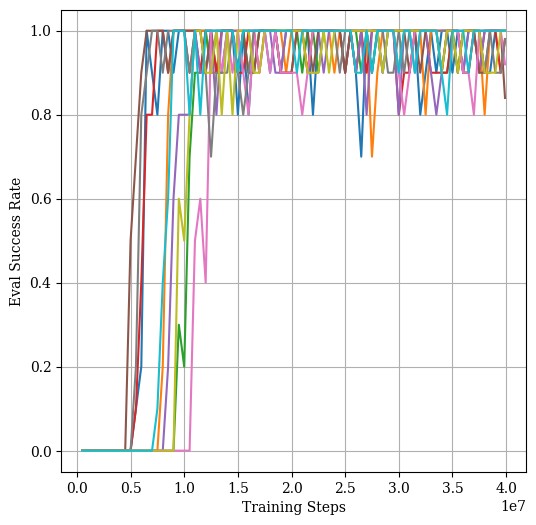

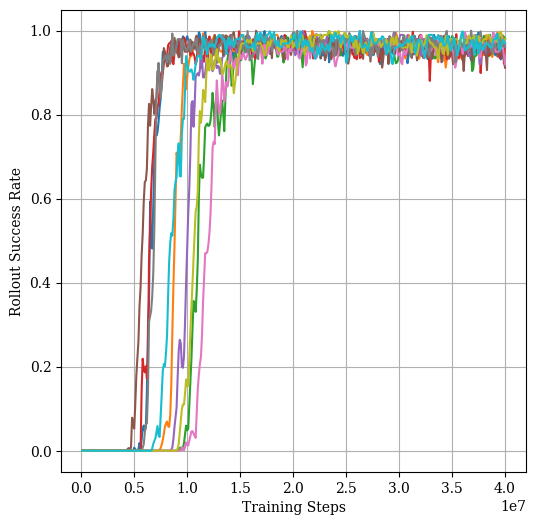

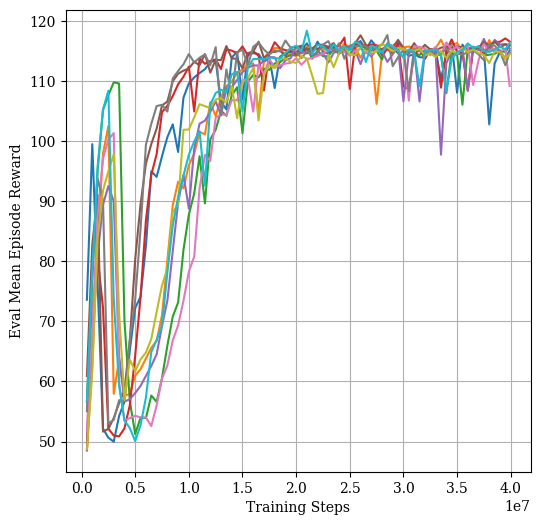

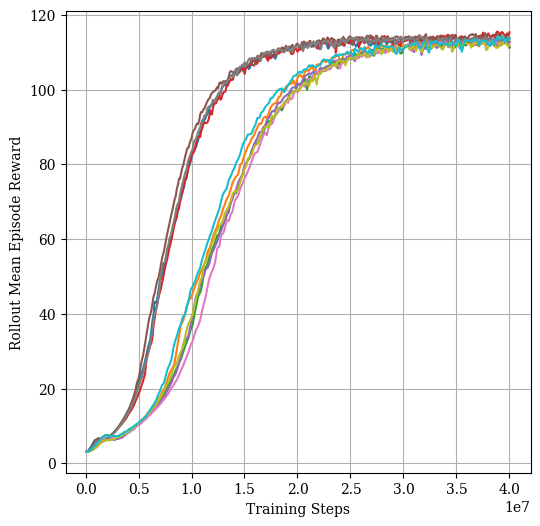

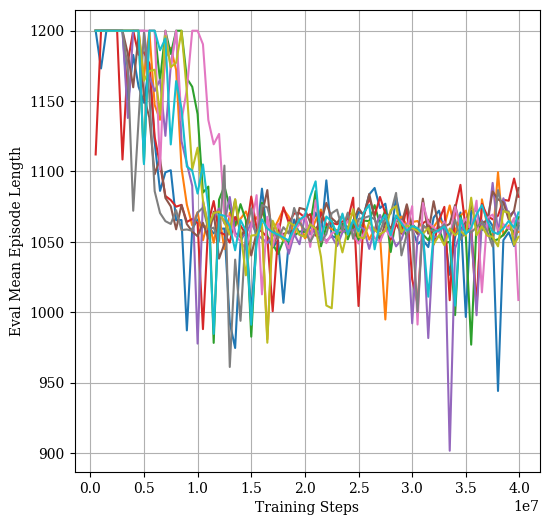

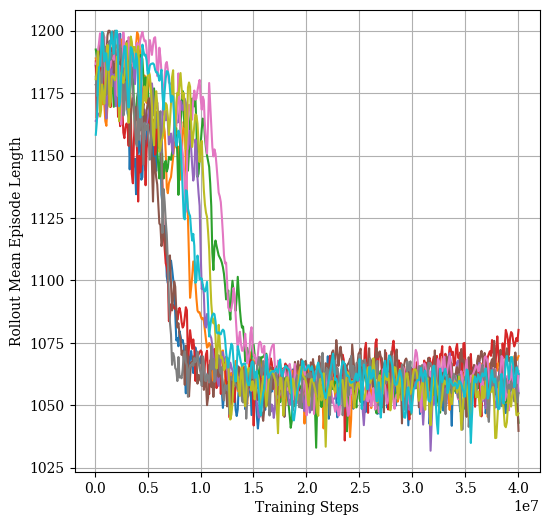

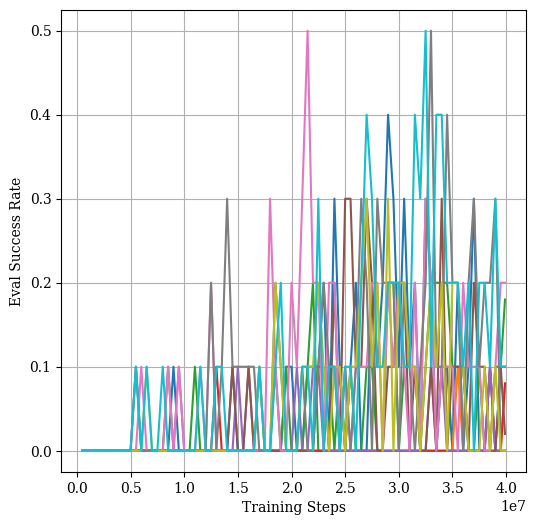

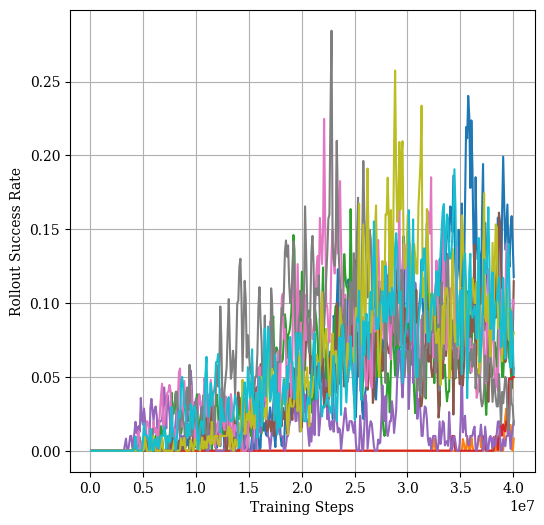

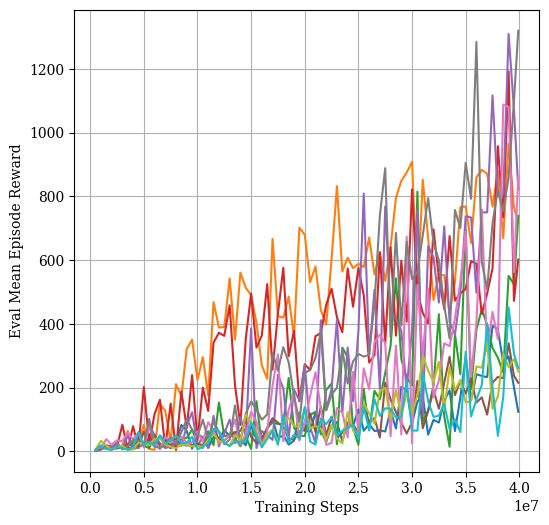

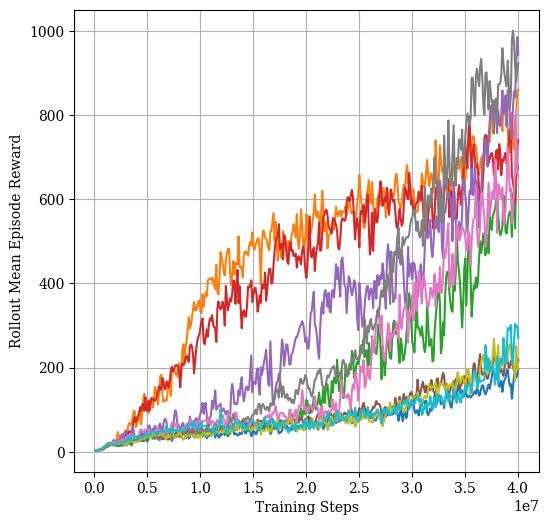

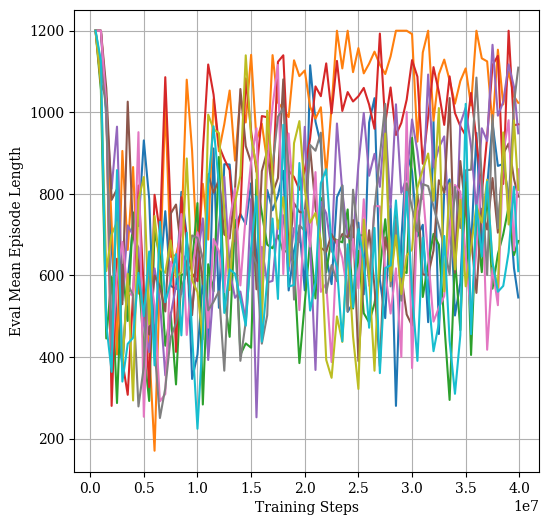

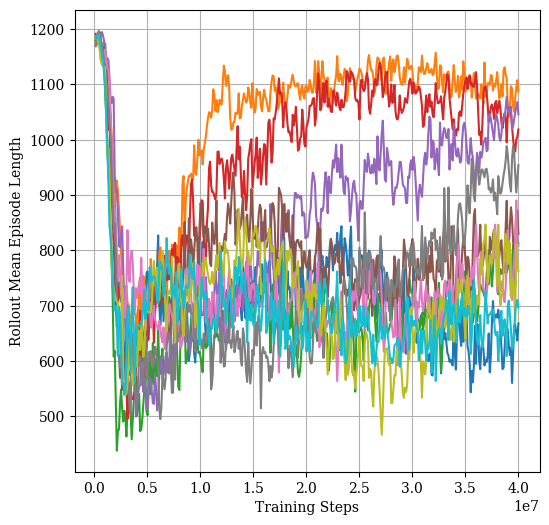

In [62]:
def plot_raw_data(ax, data, col_name="success_rate"):
    #plot the data line onto the given figure
    success_rate_columns = [col for col in data.columns if col_name in col]
    for col in success_rate_columns:
        ax.plot(data.iloc[:,0], data[col], label= f"{col}")


fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, guided_eval_success_data_interp, "success_rate")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Eval Success Rate")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, guided_rollout_success_data_interp, "success_rate")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Rollout Success Rate")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, guided_eval_ep_rew_data_interp, "mean_reward")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Eval Mean Episode Reward")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, guided_rollout_ep_rew_data_interp, "ep_rew_mean")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Rollout Mean Episode Reward")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, guided_eval_ep_len_data_interp, "mean_ep_length")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Eval Mean Episode Length")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, guided_rollout_ep_len_data_interp, "ep_len_mean")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Rollout Mean Episode Length")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, shaped_eval_success_data_interp, "success_rate")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Eval Success Rate")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, shaped_rollout_success_data_interp, "success_rate")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Rollout Success Rate")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, shaped_eval_ep_rew_data_interp, "mean_reward")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Eval Mean Episode Reward")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, shaped_rollout_ep_rew_data_interp, "ep_rew_mean")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Rollout Mean Episode Reward")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, shaped_eval_ep_len_data_interp, "mean_ep_length")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Eval Mean Episode Length")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, shaped_rollout_ep_len_data_interp, "ep_len_mean")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Rollout Mean Episode Length")
plt.show()

In [63]:
guided_eval_success_data_interp.tail()

,interp_global_step,cool-silence-750 - eval/success_rate,morning-sound-749 - eval/success_rate,devout-terrain-748 - eval/success_rate,rich-field-747 - eval/success_rate,flowing-glitter-746 - eval/success_rate,smooth-flower-745 - eval/success_rate,flowing-feather-744 - eval/success_rate,efficient-flower-743 - eval/success_rate,desert-pine-742 - eval/success_rate,lucky-silence-739 - eval/success_rate
390,39499994,1.0,0.900094,1.0,0.900062,1.0,0.999876,0.999906,0.900062,1.0,1.0
391,39599994,1.0,0.920094,1.0,0.920062,1.0,0.959876,0.979906,0.920062,1.0,1.0
392,39699994,1.0,0.940094,1.0,0.940062,1.0,0.919875,0.959906,0.940062,1.0,1.0
393,39799994,1.0,0.960094,1.0,0.960062,1.0,0.879875,0.939906,0.960062,1.0,1.0
394,39899994,1.0,0.980095,1.0,0.980063,1.0,0.839875,0.919905,0.980063,1.0,1.0


In [64]:
shaped_rollout_success_data_interp

,interp_global_step,fresh-sunset-769 - rollout/success_rate,silvery-shadow-768 - rollout/success_rate,ethereal-durian-766 - rollout/success_rate,dauntless-sun-765 - rollout/success_rate,rural-silence-763 - rollout/success_rate,frosty-moon-762 - rollout/success_rate,ethereal-waterfall-761 - rollout/success_rate,twilight-dust-760 - rollout/success_rate,smooth-moon-759 - rollout/success_rate,likely-sea-758 - rollout/success_rate
0,131072,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,231072,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,331072,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,431072,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,531072,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
395,39631072,0.124443,0.013611,0.060000,0.049167,0.012778,0.076389,0.098335,0.024443,0.074443,0.107502
396,39731072,0.151240,0.017520,0.057520,0.032480,0.001240,0.067520,0.061240,0.047520,0.096279,0.056201
397,39831072,0.158870,0.002261,0.042261,0.047739,0.008870,0.052261,0.068870,0.032261,0.073391,0.094348
398,39931072,0.140503,0.000000,0.052998,0.050000,0.016499,0.075996,0.102495,0.030000,0.076499,0.074004


In [65]:
def get_mean_and_std(data):
    #get the mean and std of each column at each time step, excluding the first column
    run_data = data.iloc[:, 1:]  # Exclude the first column
    mean = run_data.mean(axis=1)
    std = run_data.std(axis=1)

    # new data frame with the first column and the mean and std
    new_data = pd.DataFrame({
        "global_step": data.iloc[:, 0],
        "mean": mean,
        "std": std
    })

    return new_data

guided_eval_success_data_mean_std = get_mean_and_std(guided_eval_success_data_interp)
guided_eval_ep_rew_data_mean_std = get_mean_and_std(guided_eval_ep_rew_data_interp)
guided_eval_ep_len_data_mean_std = get_mean_and_std(guided_eval_ep_len_data_interp)

guided_rollout_success_data_mean_std = get_mean_and_std(guided_rollout_success_data_interp)
guided_rollout_ep_len_data_mean_std = get_mean_and_std(guided_rollout_ep_len_data_interp)
guided_rollout_ep_rew_data_mean_std = get_mean_and_std(guided_rollout_ep_rew_data_interp)

shaped_eval_success_data_mean_std = get_mean_and_std(shaped_eval_success_data_interp)
shaped_eval_ep_rew_data_mean_std = get_mean_and_std(shaped_eval_ep_rew_data_interp)
shaped_eval_ep_len_data_mean_std = get_mean_and_std(shaped_eval_ep_len_data_interp)

shaped_rollout_success_data_mean_std = get_mean_and_std(shaped_rollout_success_data_interp)
shaped_rollout_ep_len_data_mean_std = get_mean_and_std(shaped_rollout_ep_len_data_interp)
shaped_rollout_ep_rew_data_mean_std = get_mean_and_std(shaped_rollout_ep_rew_data_interp)

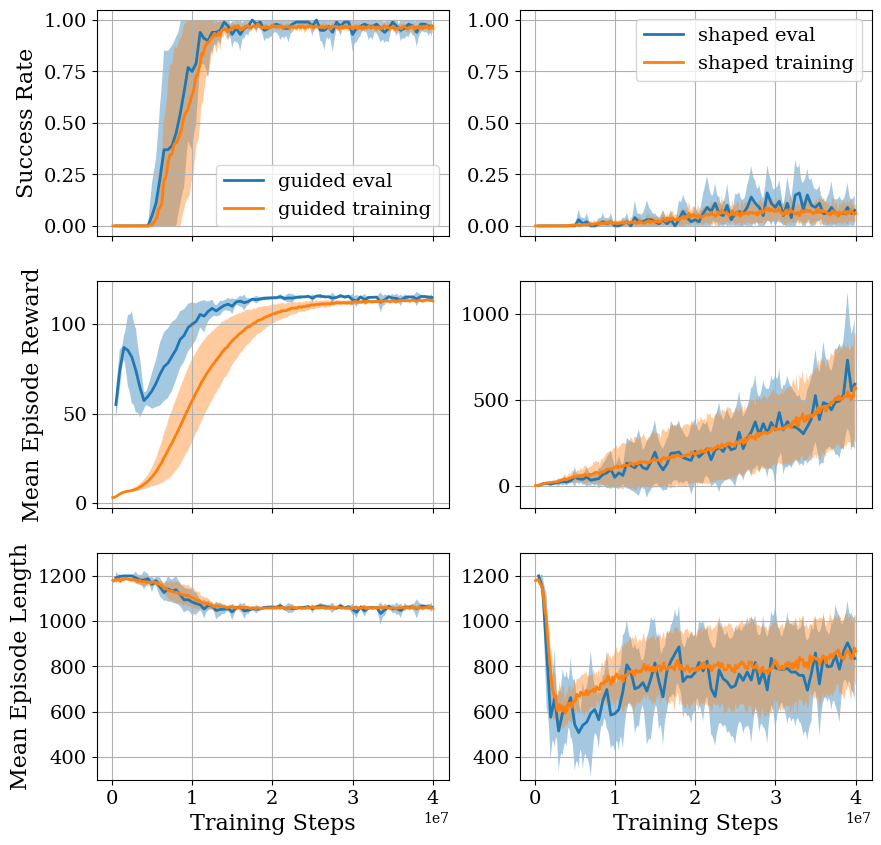

In [85]:
def plot_mean_and_Nstd(ax, data, label="", N=3, legend=True, clip=False):
    #plot mean as a line and N*std as a shaded area
    ax.plot(data["global_step"], data["mean"], label=label, linewidth=2)

    if clip:
        upper = np.clip(data["mean"] + N * data["std"], 0, 1)
        lower = np.clip(data["mean"] - N * data["std"], 0, 1)
    else:
        upper = data["mean"] + N * data["std"]
        lower = data["mean"] - N * data["std"]
    ax.fill_between(
        data["global_step"],
        lower,
        upper,
        alpha=0.4,
    )
    if legend:
        ax.legend(fontsize=14)
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=14)

fig, ax = plt.subplots(3,2, figsize=(10, 10), sharex=True)
N = 1
plot_mean_and_Nstd(ax[0,0], guided_eval_success_data_mean_std, label="guided eval", N=N, clip=True)
plot_mean_and_Nstd(ax[0,0],
                   guided_rollout_success_data_mean_std,
                   label="guided training",
                   N=N,
                   clip=True)
plot_mean_and_Nstd(ax[0,1], shaped_eval_success_data_mean_std, label="shaped eval", N=N, clip=True)
plot_mean_and_Nstd(ax[0,1], shaped_rollout_success_data_mean_std, label="shaped training", N=N, clip=True)
ax[0, 0].set_ylabel("Success Rate", fontsize=16)
ax[0, 0].set_ylim(-.05, 1.05)
ax[0,1].set_ylim(-.05, 1.05)

plot_mean_and_Nstd(ax[1,0], guided_eval_ep_rew_data_mean_std, label="eval", N=N, legend=False)
plot_mean_and_Nstd(ax[1, 0],
                   guided_rollout_ep_rew_data_mean_std,
                   label="training",
                   N=N,
                   legend=False)
plot_mean_and_Nstd(ax[1,1], shaped_eval_ep_rew_data_mean_std, label="eval", N=N, legend=False)
plot_mean_and_Nstd(ax[1,1], shaped_rollout_ep_rew_data_mean_std, label="training", N=N, legend=False)
ax[1,0].set_ylabel("Mean Episode Reward", fontsize=16)

plot_mean_and_Nstd(ax[2,0], guided_eval_ep_len_data_mean_std, label="eval", N=N, legend=False)
plot_mean_and_Nstd(ax[2,0],
                   guided_rollout_ep_len_data_mean_std,
                   label="training",
                   N=N,
                   legend=False)
plot_mean_and_Nstd(ax[2,1], shaped_eval_ep_len_data_mean_std, label="eval", N=N, legend=False)
plot_mean_and_Nstd(ax[2, 1],
                   shaped_rollout_ep_len_data_mean_std,
                   label="training",
                   N=N,
                   legend=False)
ax[2, 0].set_ylim(300, 1300)
ax[2,1].set_ylim(300, 1300)
ax[2,0].set_ylabel("Mean Episode Length", fontsize=16)
ax[2, 0].set_xlabel("Training Steps", fontsize=16)
ax[2,1].set_xlabel("Training Steps", fontsize=16)
plt.savefig(
    "data/training_metrics_mean_std.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()